In [1]:
import numpy as np
import torch
import torch.nn as nn
import sys
sys.path.append("../../")
from vi_rnn.vae import VAE
from vi_rnn.train import train_VAE
from torch.utils.data import DataLoader, Dataset
from vi_rnn.datasets import Mante, Mante_Teacher
from py_rnn.model import RNN, predict
from py_rnn.train import train_rnn
from py_rnn.train import save_rnn, load_rnn
from vi_rnn.utils import *
import matplotlib.pyplot as plt
from vi_rnn.saving import save_model, load_model
from py_rnn.default_params import get_default_params

%matplotlib inline

In [31]:
train_teacher =True # load already trained teacher model
# data_dir = "../../data/student_teacher/"  # store inferred model
model_dir = "../../models/students/"  # store teacher RNN
cuda = True  # toggle if GPU is available
neuromodulation = "additive"

In [32]:
# initialise teacher RNN
model_params, training_params = get_default_params(n_rec=60)
training_params["n_epochs"] = 1000
training_params["l2_rates_reg"] = 0.1
model_params['rank']= 1
model_params['n_inp'] = 2
training_params["neuromodulation"] = neuromodulation
model_params['neuromodulation'] = neuromodulation
model_params['ds'] = 2
data_dir = f"../../data/mante_{neuromodulation}_rank_{model_params['rank']}/"
rnn_reach = RNN(model_params)

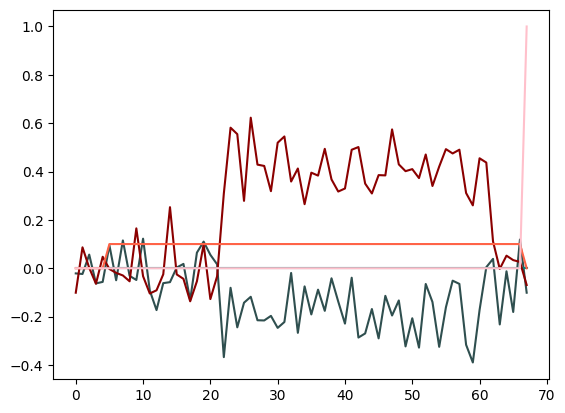

In [33]:
# Plot an example trial for teacher RNN

mante = Mante()
stimulus, targets, mask=mante.__getitem__(0)
plt.plot(stimulus[:,0], c='darkslategray')
plt.plot(stimulus[:,2], c='teal')
plt.plot(stimulus[:,1], c='darkred')
plt.plot(stimulus[:,3], c='tomato')

plt.plot(targets, c='pink')

In [34]:
task_params_teacher = {}
# train or load teacher RNN
if train_teacher:
    losses, reg_losses = train_rnn(
        rnn_reach, training_params, mante, sync_wandb=False
    )
    save_rnn(
        data_dir + f"rnn_mante_{neuromodulation}_rank_{model_params['rank']}_3",
        rnn_reach,
        model_params,
        task_params_teacher,
        training_params,
    )
else:
    rnn_reach, model_params, task_params_teacher, training_params = load_rnn(
        data_dir + f"rnn_mante_{neuromodulation}_rank_{model_params['rank']}_2"
    )

using l2 rates reg
epoch 1000 / 1000: time=29.9 s, task loss=0.02375, reg loss=0.28205
Done. Training took 29.9 sec.


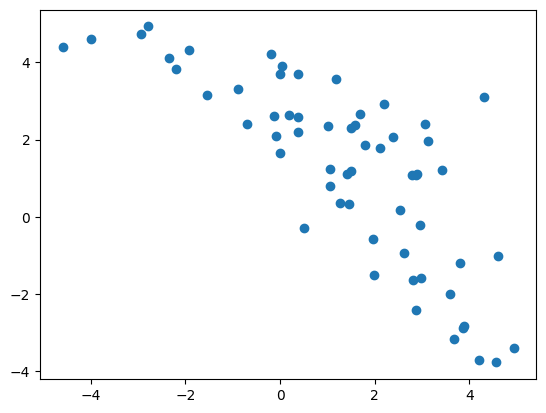

In [35]:
plt.scatter(rnn_reach.rnn.A[:, 0].detach(), rnn_reach.rnn.A[:, 1].detach())

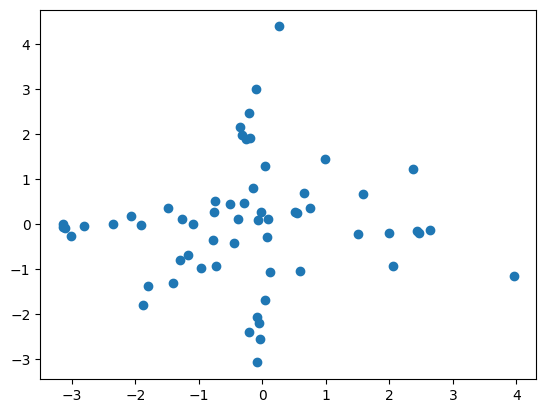

In [36]:
plt.scatter(rnn_reach.rnn.w_inp[0, :].detach(), rnn_reach.rnn.w_inp[1, :].detach())

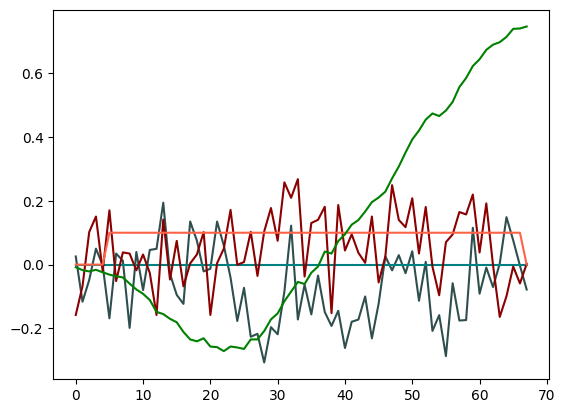

In [37]:
stimulus, targets, mask=mante.__getitem__(0)
plt.plot(stimulus[:,0], c='darkslategray')
plt.plot(stimulus[:,2], c='teal')
plt.plot(stimulus[:,1], c='darkred')
plt.plot(stimulus[:,3], c='tomato')

out = rnn_reach(stimulus[:, :2].unsqueeze(0), s=stimulus[:, 2:].unsqueeze(0))
plt.plot(out[1].view(68).detach().numpy(), c='green')

In [38]:
# Extract weights
U, V, B = extract_orth_basis_rnn(rnn_reach)
I = rnn_reach.rnn.w_inp.detach()
A = rnn_reach.rnn.A.detach()

In [39]:
# Generate data using teacher RNN, used for training student RNN
batch_size = 4
task_params = {
    "name": "rdm",
    "n_neurons": rnn_reach.rnn.N,
    "out": "currents",
    "r0": 0,
    "R_x": 0.1,
    "R_z": 0.05,
    "du": model_params["n_inp"],
    "dz": 1,
    "n_trials": 400,
    "neuromodulation": model_params["neuromodulation"]
}
task = Mante_Teacher(task_params, task_params_teacher, U, V, B, I, A, decay=0.9)
data_loader = DataLoader(task, batch_size=batch_size, shuffle=True)

In [40]:
# Initialise VI / student setup

dim_z = 1
dim_N = task_params["n_neurons"]
dim_x = task_params["n_neurons"]
dim_u = 2
bs = 10
cuda = False
n_epochs = 170
wandb = False
# initialise encoder
enc_params = {"obs_grad": True, "init_scale": 0.1}

# initialise prior
prior_params = {
    "train_noise_x": True,
    "train_noise_z": True,
    "train_noise_z_t0": True,
    "init_noise_z": 0.1,
    "init_noise_z_t0": 1,
    "init_noise_x": 0.1,
    "scalar_noise_z": "Cov",
    "scalar_noise_x": False,
    "scalar_noise_z_t0": "Cov",
    "identity_readout": True,
    "activation": "relu",
    "exp_par": True,
    "shared_tau": 0.7,
    "readout_rates": task_params["out"],
    "train_obs_bias": False,
    "train_obs_weights": False,
    "train_latent_bias": False,
    "train_neuron_bias": True,
    "orth": False,
    "m_norm": False,
    "weight_dist": "uniform",
    "weight_scaler": 1,  # /dim_N,
    "initial_state": "trainable",
    "out_nonlinearity": "identity",
    "neuromodulation": "additive"
}


training_params = {
    "lr": 1e-3,
    "lr_end": 1e-5,
    "step_size":1,
    "opt_eps": 1e-8,
    "gamma":.99,
    "n_epochs": n_epochs,
    "grad_norm": 0,
    "bootstrap": False,
    "eval_epochs": 50,
    "batch_size": bs,
    "cuda": cuda,
    "smoothing": 20,
    "freq_cut_off": 10000,
    "sim_obs_noise": 0,
    "sim_latent_noise": 1,
    "k": 64,
    "loss_f": "opt_VGTF",
    "resample": "systematic",  # , multinomial or none"
    "run_eval": False,
    "smooth_at_eval": False,
    "sim_v":True,
    "neuromodulation": "additive"
}


VAE_params = {
    "dim_x": dim_x,
    "dim_z": dim_z,
    "dim_u": dim_u,
    "dim_N": dim_N,
    "dim_s": 2,
    "enc_architecture": "Inv_Obs",
    "enc_params": enc_params,
    "prior_architecture": "PLRNN",
    "prior_params": prior_params,
    "causal":True,
}
vae = VAE(VAE_params)

Neuromodulation type: additive
using ReLU activation
using uniform init
weight scaler 1


In [41]:
# vae, _,_,_ = load_model(name=model_dir + "mante_student")

In [42]:
# Train

train_VAE(
    vae,
    training_params,
    task,
    sync_wandb=wandb,
    out_dir=model_dir,
    fname=None,
    store_train_stats=False,
)

Training on : cpu
Learning rate decay factor 0.9732743861581503
epoch 1 loss: 562.8096, ll: -562.8096, ll_x: 561.4731, ll_z: -1.3086 H: 2.6512, alpha: 0.96, lr: 0.001000, N_z: 0.0997, N_x: 0.1028
epoch 2 loss: 552.4109, ll: -552.4109, ll_x: 551.0909, ll_z: -1.3218 H: 2.6486, alpha: 0.96, lr: 0.000990, N_z: 0.0994, N_x: 0.1031
epoch 3 loss: 544.5883, ll: -544.5883, ll_x: 543.2802, ll_z: -1.3301 H: 2.6453, alpha: 0.96, lr: 0.000980, N_z: 0.0990, N_x: 0.1035
epoch 4 loss: 535.1208, ll: -535.1208, ll_x: 533.8229, ll_z: -1.3373 H: 2.6427, alpha: 0.96, lr: 0.000970, N_z: 0.0985, N_x: 0.1040
epoch 5 loss: 524.4962, ll: -524.4962, ll_x: 523.2086, ll_z: -1.3437 H: 2.6389, alpha: 0.96, lr: 0.000961, N_z: 0.0979, N_x: 0.1046
epoch 6 loss: 513.0326, ll: -513.0326, ll_x: 511.7540, ll_z: -1.3497 H: 2.6360, alpha: 0.96, lr: 0.000951, N_z: 0.0973, N_x: 0.1051
epoch 7 loss: 500.8654, ll: -500.8654, ll_x: 499.5964, ll_z: -1.3550 H: 2.6318, alpha: 0.96, lr: 0.000941, N_z: 0.0967, N_x: 0.1058
epoch 8 loss

[]

In [30]:
vae.rnn.transition.nm_params.shape

torch.Size([60, 0])

In [36]:
save_model(vae, training_params, task_params, name=model_dir + "mante_additive_additive_4")

'../../models/students/mante_additive_additive_4'

In [14]:
vae, _,_,_ = load_model(name=model_dir + "mante_additive_additive_4")

dict_keys(['dim_x', 'dim_z', 'dim_u', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'causal', 'rnn_params', 'rnn_architecture'])
Neuromodulation type: additive
using ReLU activation
using uniform init
weight scaler 1


c:\Users\kaleab.belay\Documents\Project\mnm\train_scripts\student_teacher\../..\vi_rnn\saving.py:125: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  d = torch.load(state_dict

In [43]:
def predict_X(
        vae, 
        trial_dur,
        eval_data,
        task_input, 
        s,
        smoothing=20,
        cut_off=0,
        freq_cut_off=10000,
        sim_obs_noise=1,
        sim_latent_noise=1,
        smooth=False, 
        neuromodulation=False,
        sim_v=True
):
    """
    Get predicted trajectories 

    Args: 
        vae (nn.Module): VAE model 
        trial_dur (int): Duration of a single trial 
        eval_data (torch.Tensor): population activity on test data 
        task_input (torch.Tensor): task input tensor 
        s (torch.tensor): neuromodulator signals  
        smoothing (int): smoothing param for the power spectrum 
        cut_off (int): cut off for the latent time series 
        freq_cut_off (int): cut off for the power spectrum 
        sim_obs_noise (float): latent noise scale 
        smooth (bool): whether to smooth the generated trajectory 

    Returns:
        trajectories (torch.tensor; n_trials, dim_x, trial_dur)
    """
    n_trials = eval_data.shape[0] if len(eval_data.shape) == 3 else 1
    with torch.no_grad(): 
        # Evaluating on one long trajectory? 
        if len(eval_data.shape) == 2: 
            # obtain an initial latent state 
            if sim_latent_noise > 1e-8: # take sample of encoder 
                z_hat, _, _, _ = vae.encoder(eval_data[:, :trial_dur]) 
            else: # take mean prediction of encoder 
                _, z_hat, _, _ = vae.encoder(eval_data[:, :trial_dur])
            # print(f'z0 shape: {z_hat.shape}')
            z0 = z_hat[:, :, 1].squeeze() 
            # print(f'z0 shape: {z0}')
            # predict latent time series now that we have initial latent state 
            Z, v = vae.rnn.get_latent_time_series(time_steps=trial_dur, 
                                               cut_off=cut_off,
                                               z0=z0,
                                               u=task_input,
                                               s=s,
                                               noise_scale=sim_latent_noise)
        else:
            # Evaluate on multiple short trajectories (trials) 
            if sim_latent_noise > 1e-8: 
                z_hat, _, _, _ = vae.encoder(eval_data.permute(0, 2, 1))
            else: 
                _, z_hat, _, _ = vae.encoder(eval_data.permute(0, 2, 1))
            z0 = z_hat[:, :, :1]
            Z, v = vae.rnn.get_latent_time_series(
                time_steps=trial_dur,
                cut_off=cut_off,
                z0=z0, 
                u=task_input,
                s=s,
                noise_scale=sim_latent_noise
            )
        # transform latent time series into observations 
        trajectories = vae.rnn.get_observation(Z, v=v, noise_scale=sim_obs_noise)
        
        if smooth: 
            window = signal.windows.hann(15) 
            data_gen = torch.from_numpy(
                zscore(
                    ndimage.convolve2d(data_gen.cpu().numpy(), window, axis=0), axis=0
                )
            )

        return trajectories.reshape(n_trials, -1, trial_dur)

In [44]:
X_pred = torch.zeros_like(task.data)
model = vae
model.eval()
for b in range(task.data.shape[0]):
    X_pred[b] = predict_X(
        model, 
        task.data.size(1),
        task.data[b].T,
        task.stim[b].T.unsqueeze(0),
        task.s[b].T.unsqueeze(0),
        # s=None
    ).reshape(dim_x, -1).T
    

torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([1, 1, 68, 1])
torch.Size([

<>:19: SyntaxWarning: invalid escape sequence '\A'
<>:19: SyntaxWarning: invalid escape sequence '\A'
C:\Users\kaleab.belay\AppData\Local\Temp\ipykernel_2972\1174682203.py:19: SyntaxWarning: invalid escape sequence '\A'
  \Additive neuromodulation")
C:\Users\kaleab.belay\AppData\Local\Temp\ipykernel_2972\1174682203.py:17: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  fig.legend([idx_i, idx_j], labels=['Neural activity', 'Predicted Neural activity'], loc='upper right')


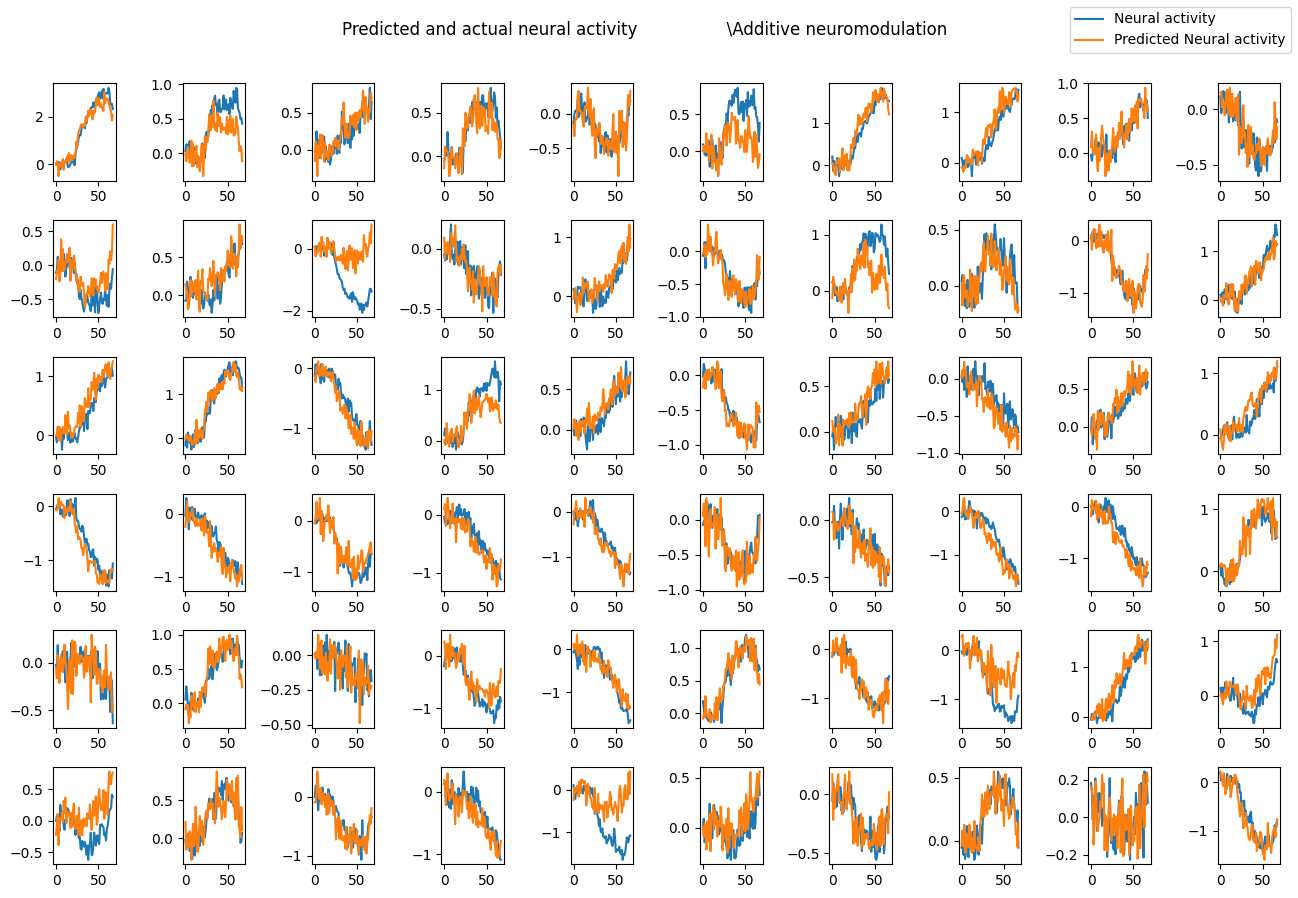

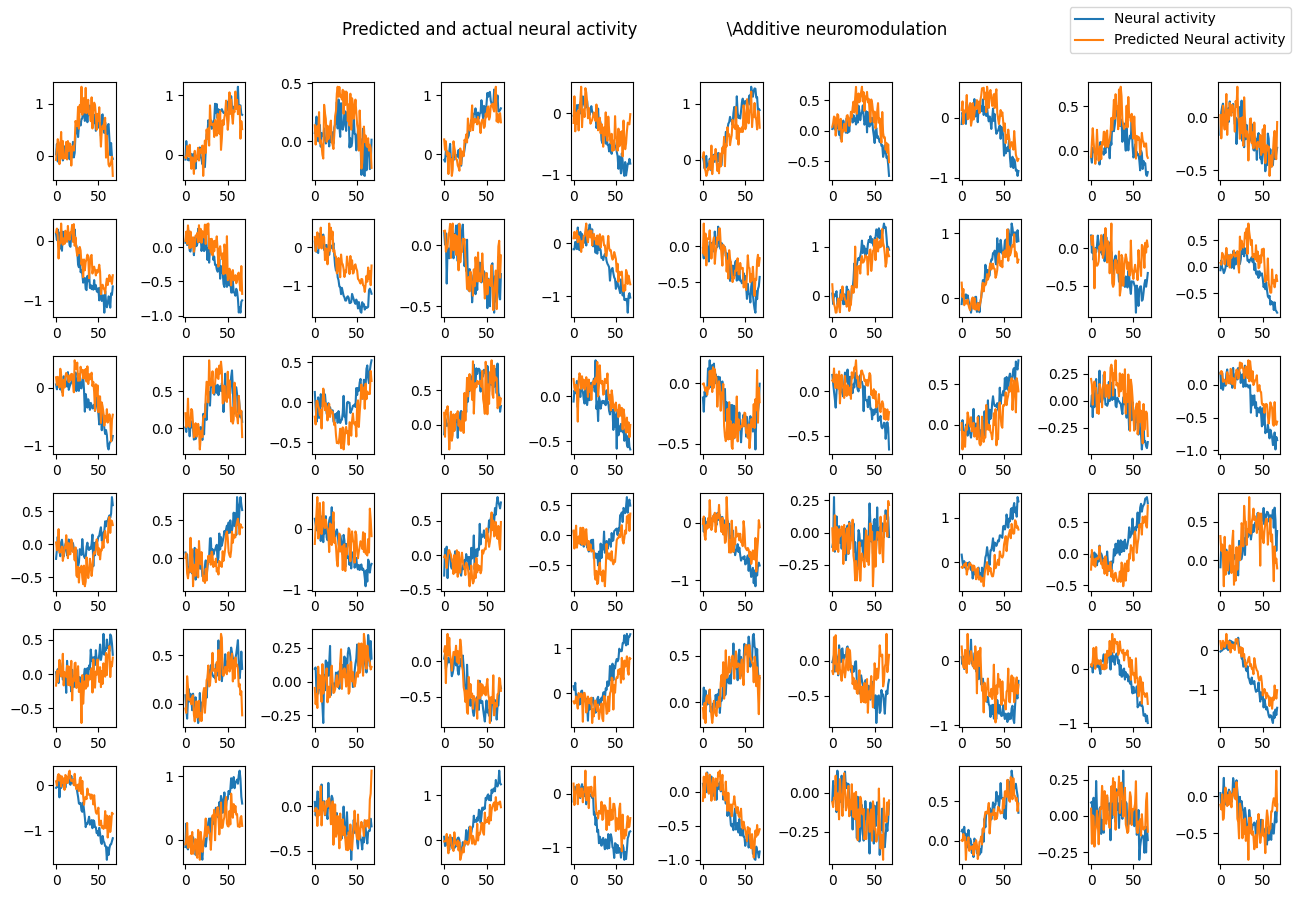

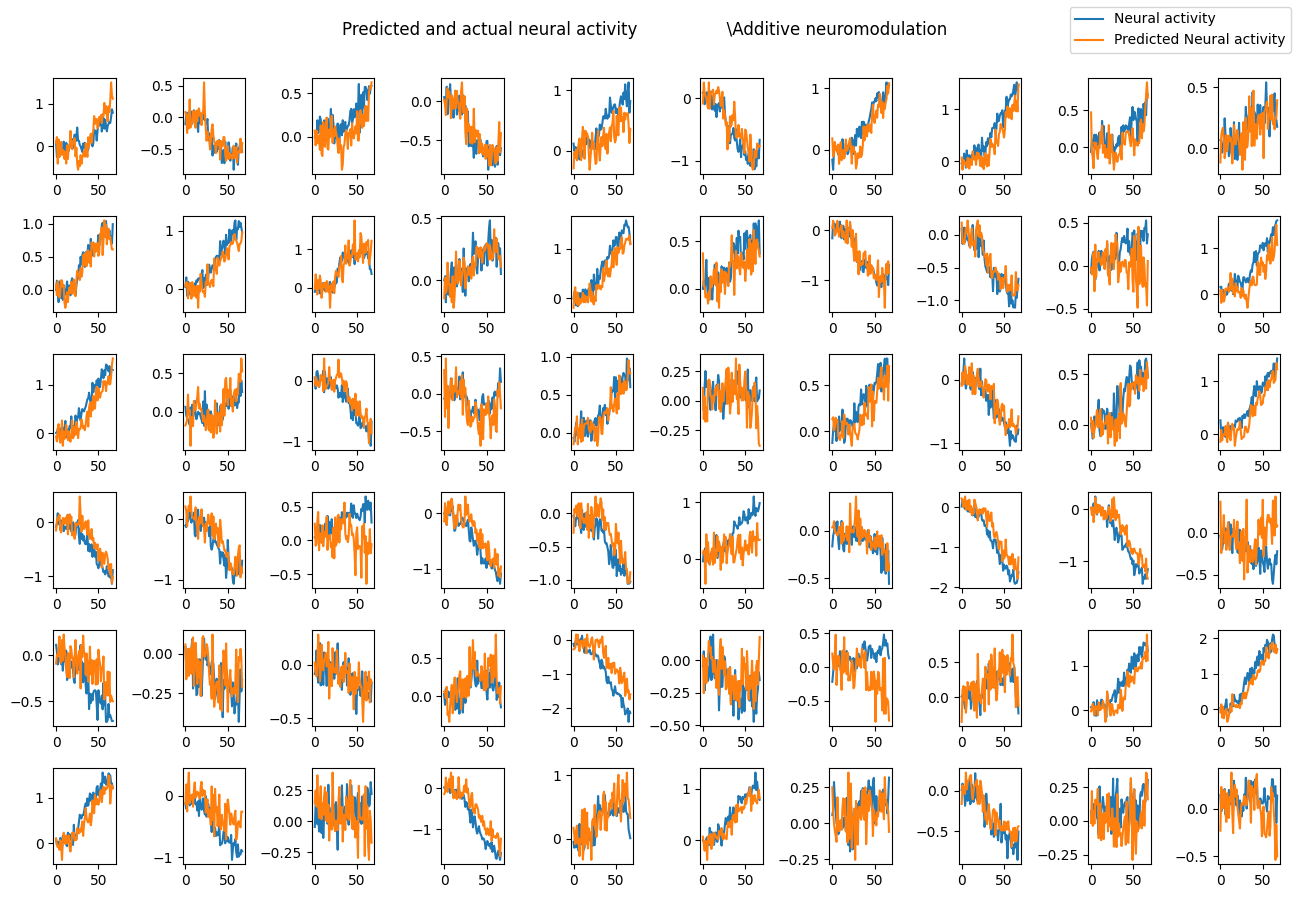

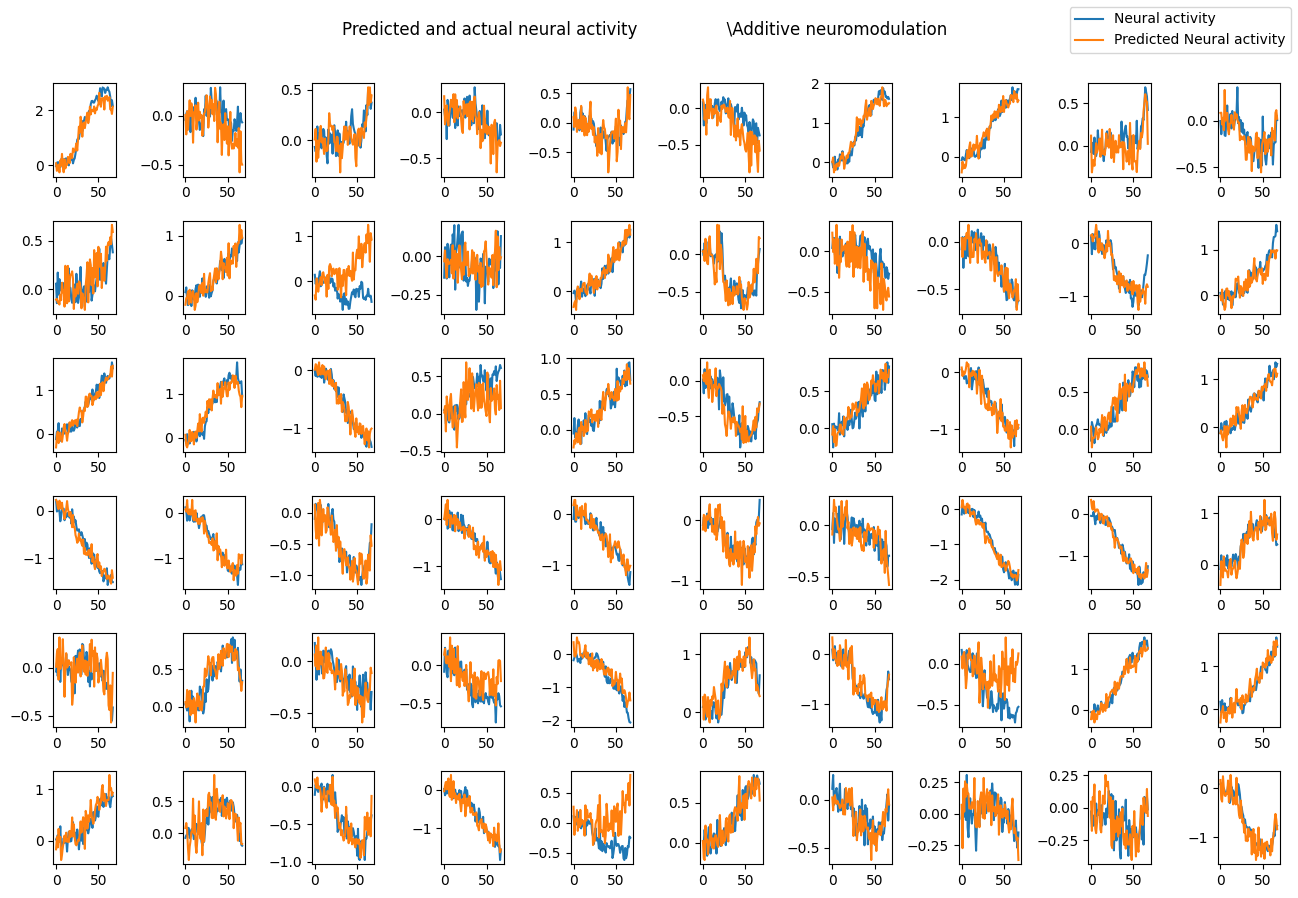

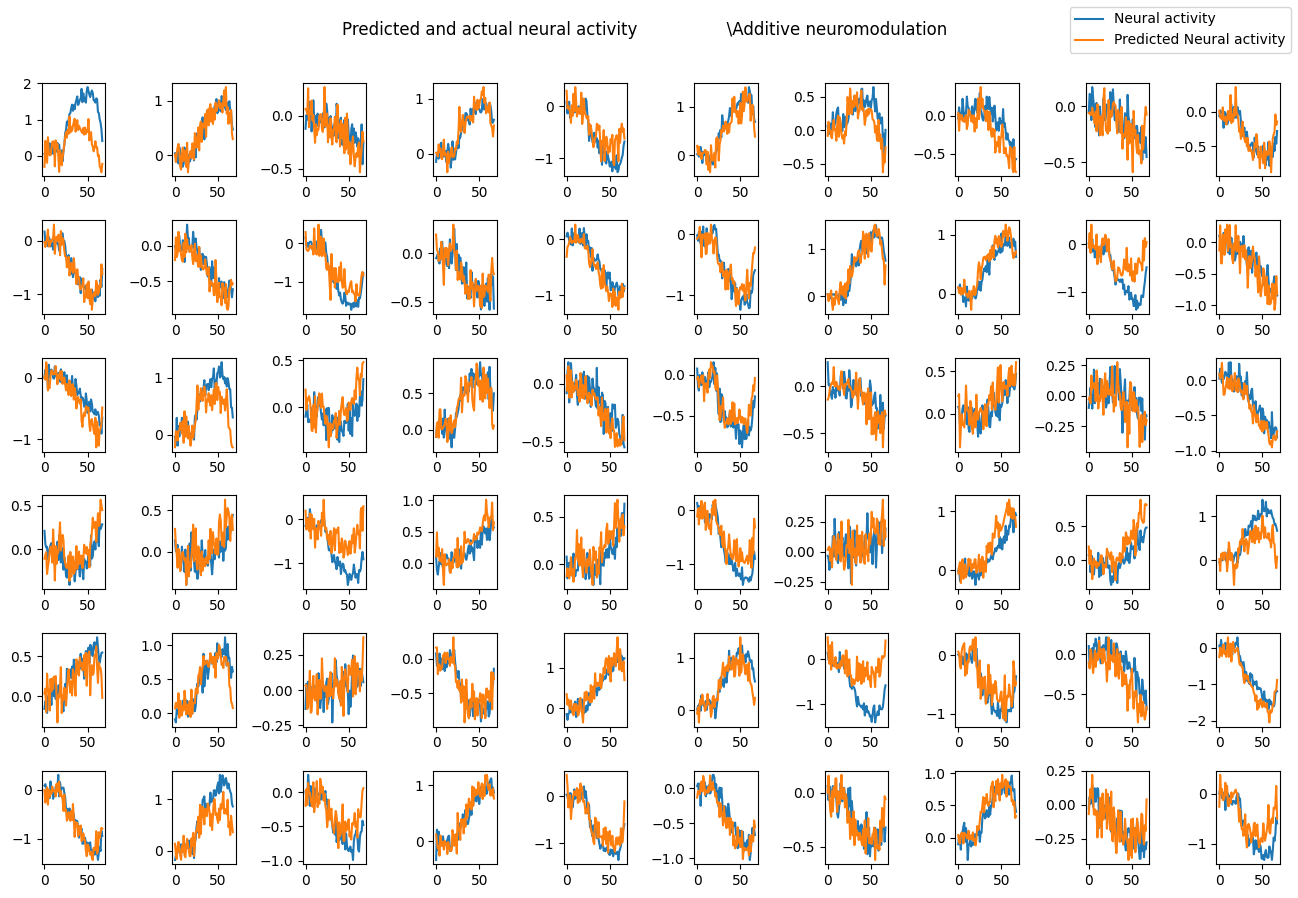

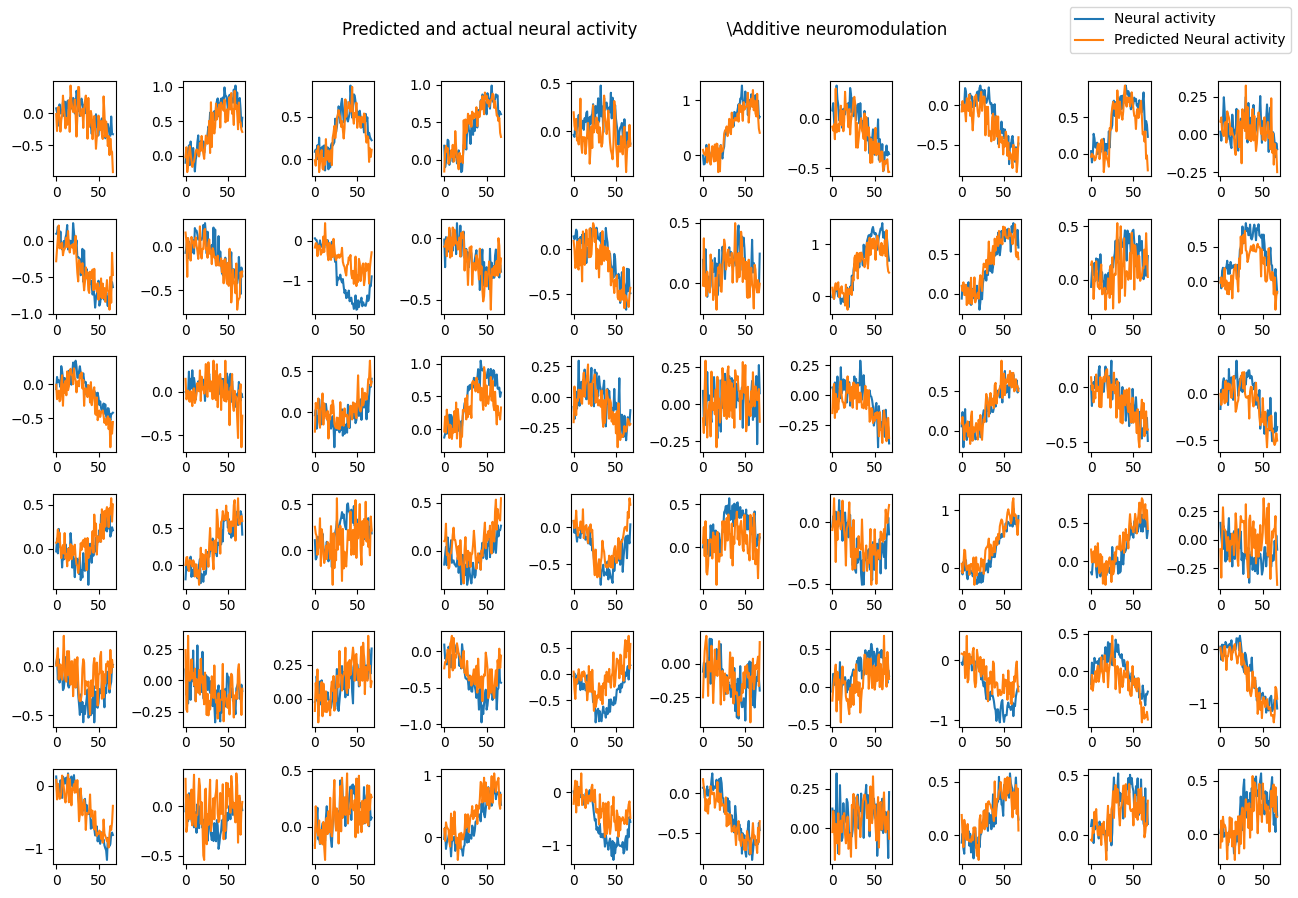

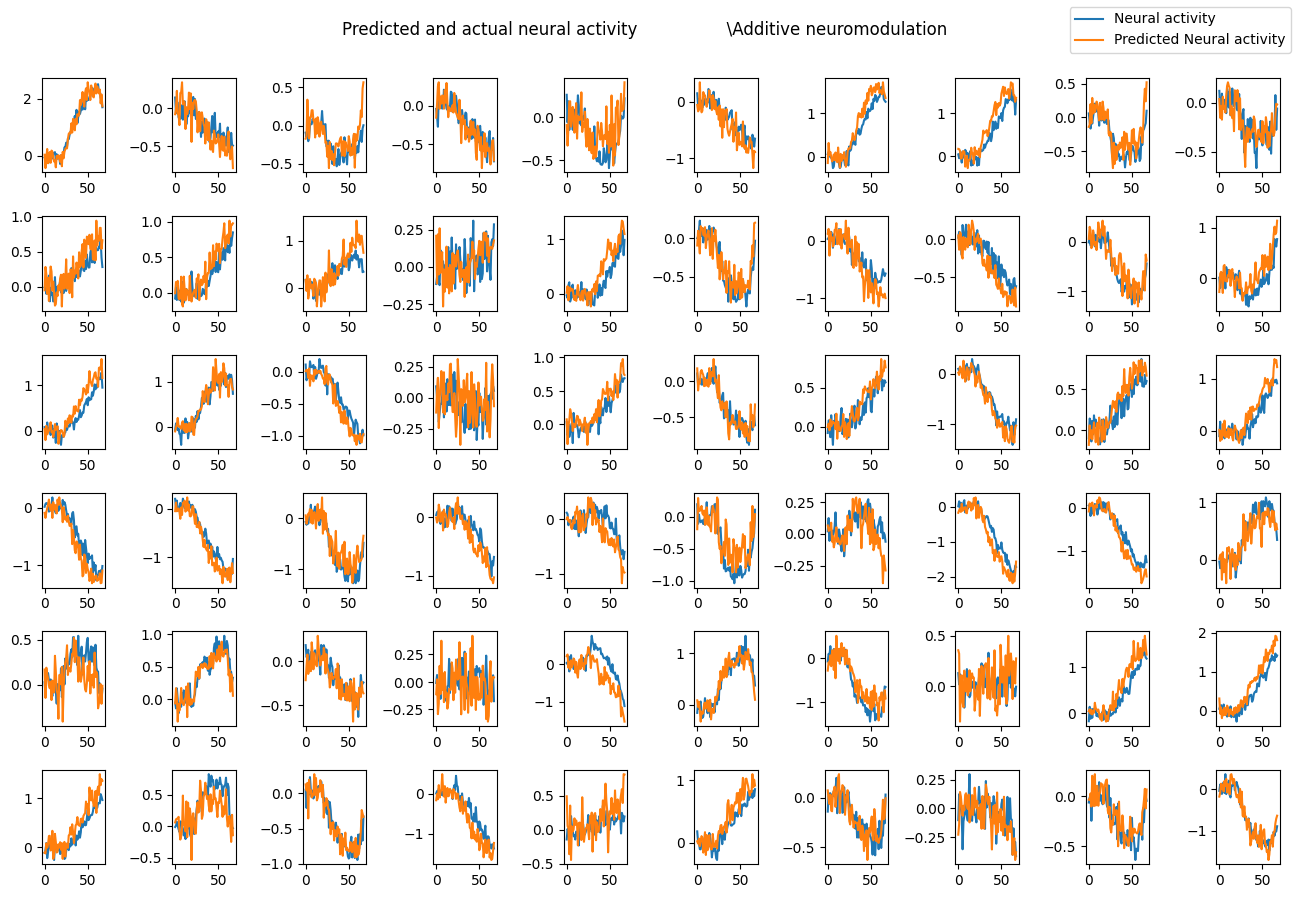

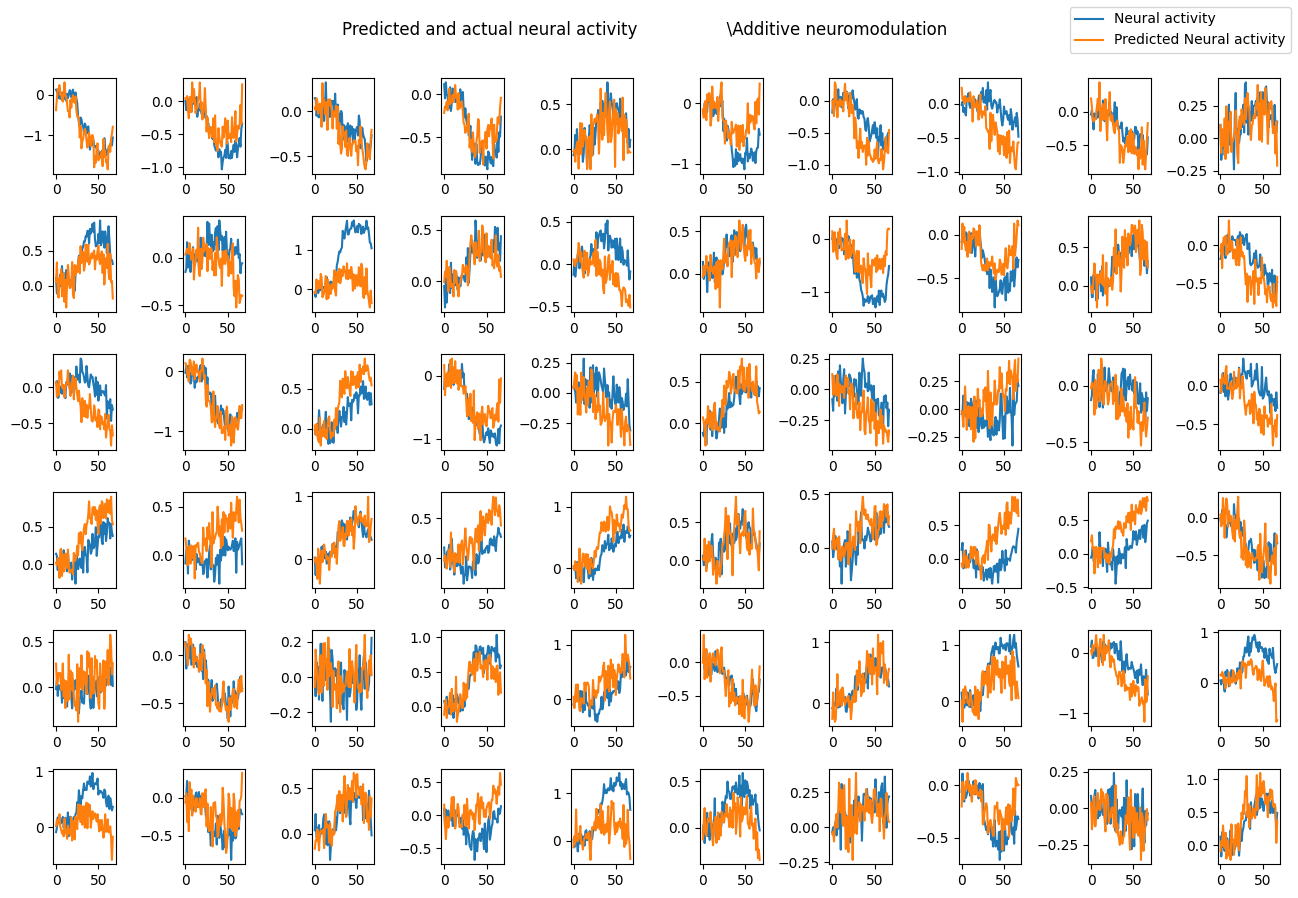

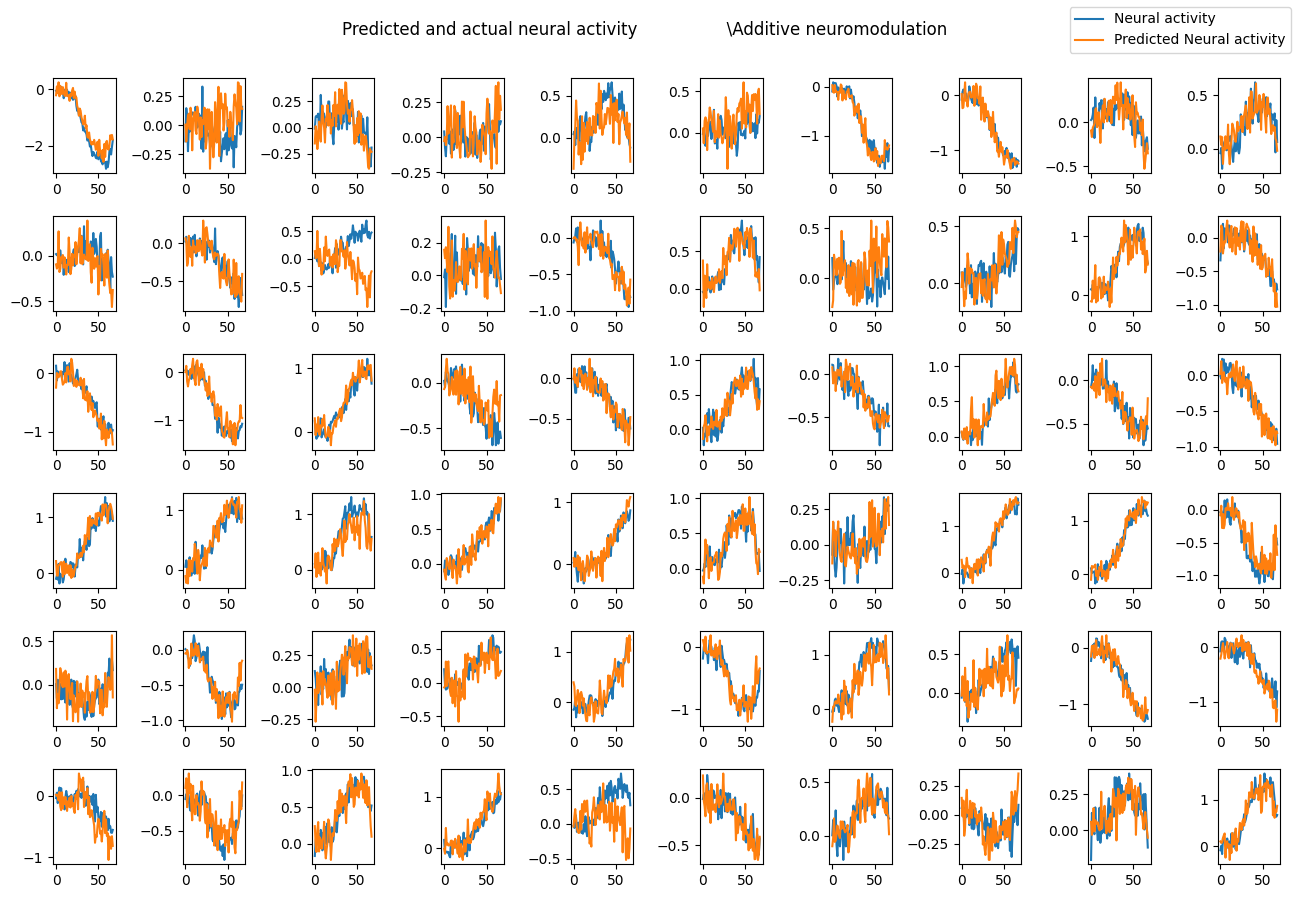

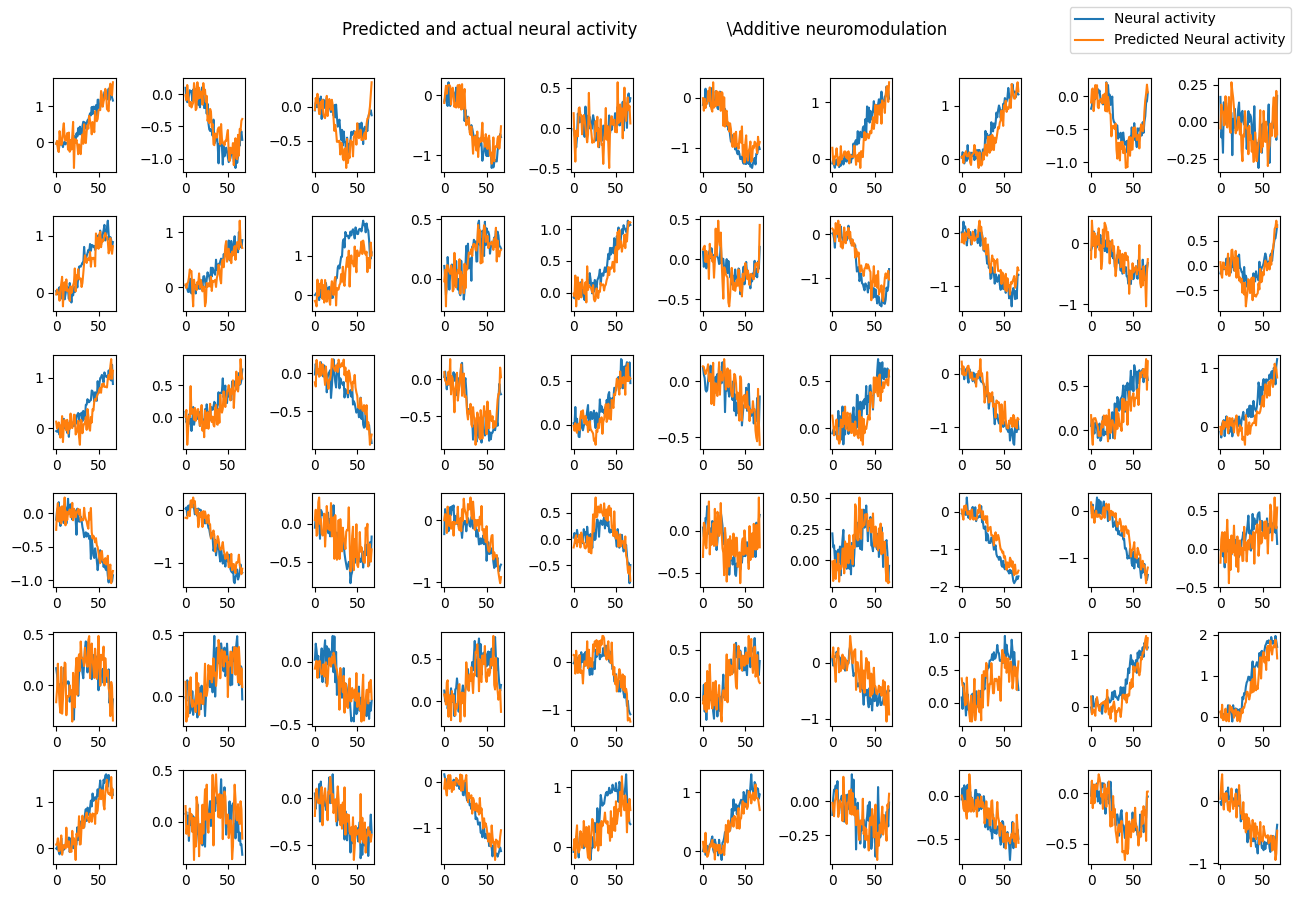

In [45]:
import matplotlib.pyplot as plt 
kl_div = []
for b in range(10):
    # compute the KL-Divergence 
    # kl_div_b = compute_KL_divergence(X_pred[b].unsqueeze(0), task.data[b])
    # kl_div.append(kl_div_b) 
    # plot population activity 
    fig, ax = plt.subplots(6, 10, figsize=(13, 9))
    idx_i, idx_j = 0, 0
    for i in range(task_params["n_neurons"]):
        ax[idx_i, idx_j].plot(task.data[b, :, i], label=f'Neural activity')
        ax[idx_i, idx_j].plot(X_pred[b, :, i], label=f'Predicted Neural activity')
        idx_j += 1
        if idx_j >= 10: 
            idx_i, idx_j = idx_i + 1, 0
        
    fig.legend([idx_i, idx_j], labels=['Neural activity', 'Predicted Neural activity'], loc='upper right')
    fig.suptitle(f"Predicted and actual neural activity\
                 \Additive neuromodulation")
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    # fig.savefig(f"{figures_dir}/mante additive/plot_{b}.png")
    # plt.show()
    
    

In [46]:
import seaborn as sns
from scipy.stats import pearsonr
# compute pearson's r

pearson_r = np.zeros((task_params["n_neurons"], task.data.size(0)))
for i in range(task_params["n_neurons"]):
    for b in range(task.data.shape[0]):
        pearson_r[i][b] = pearsonr(task.data[b, :, i], X_pred[b, :, i])[0]

In [47]:
pearson_r.mean()

0.601604927299494

Text(0.5, 1.0, 'Pearson $R$ heatmap')

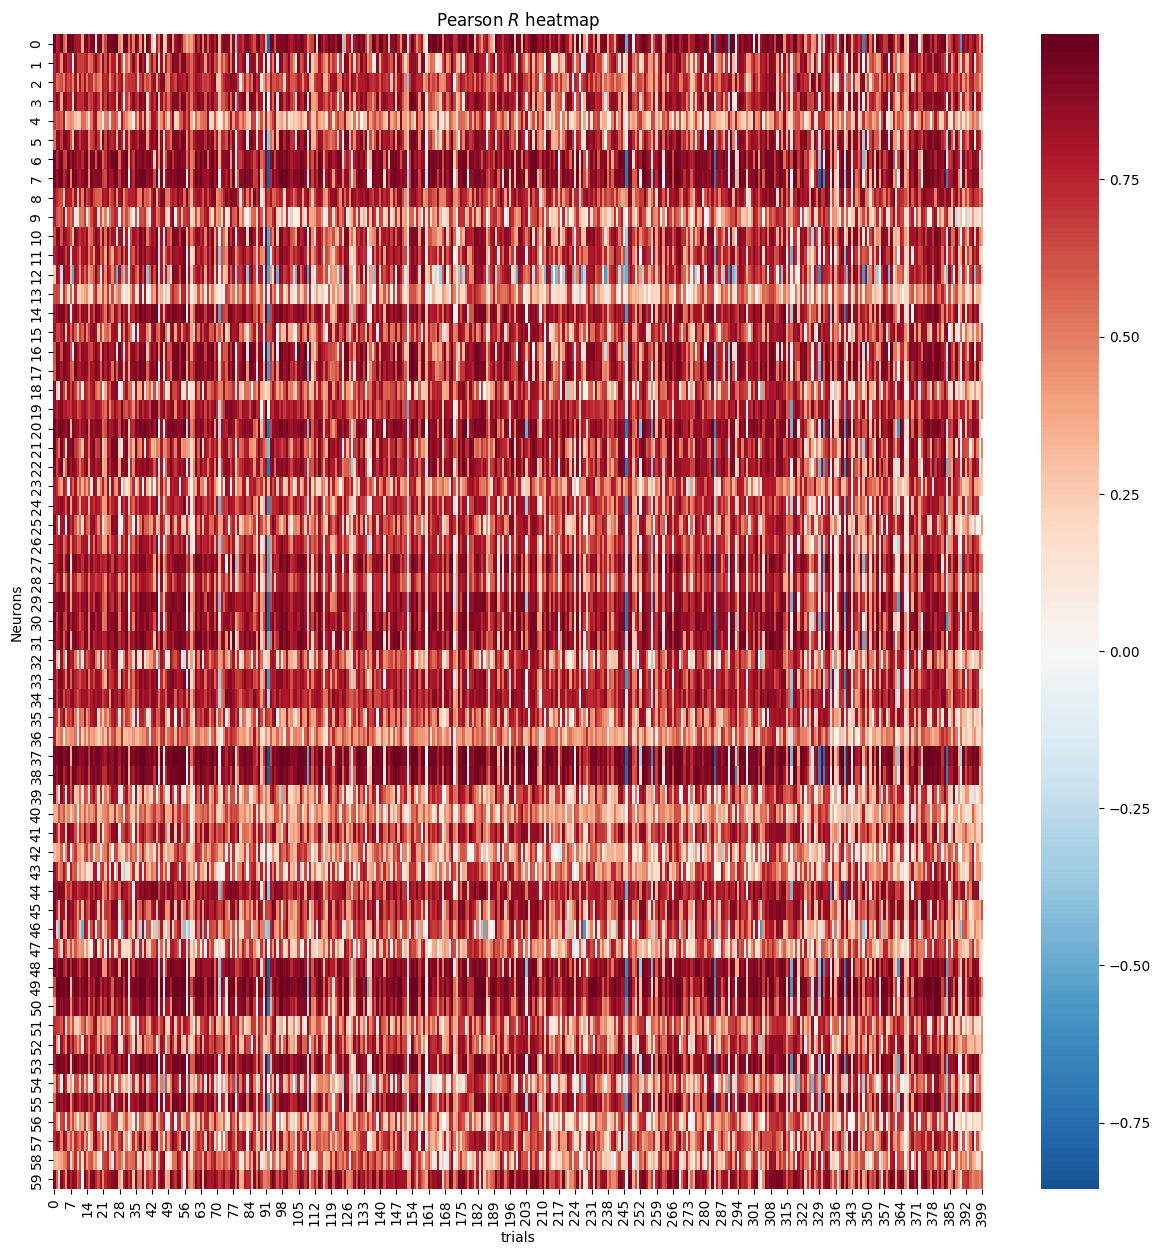

In [48]:
plt.figure(figsize=(15, 15))
# r2_arr[r2_arr < -1] = -1
sns.heatmap(pearson_r[:, :], annot=False, cmap='RdBu_r', center=0, cbar=True)
# x_ticks = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]
# x_labels = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]
# plt.xticks(x_ticks, x_labels)
plt.ylabel('Neurons')
plt.xlabel('trials')
plt.title(f'Pearson $R$ heatmap')
# plt.savefig('rank_scaling_pearson_r.png')

Text(0.5, 1.0, 'Student activity projected on student latent space')

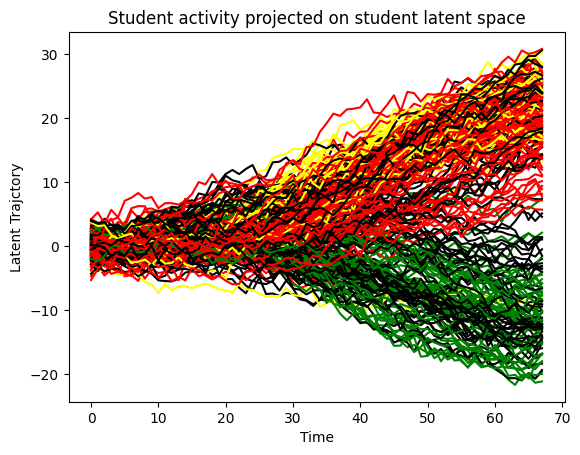

In [49]:
z_stud_stud = X_pred@model.rnn.transition.m
I = model.rnn.transition.Wu.detach().numpy()
for b in range(z_stud_stud.shape[0]):
    trial = z_stud_stud[b].detach().cpu().numpy()
    if task.s[b, :, 0].max() > 0 and task.stim[b, :, 0].mean() > 0:
        plt.plot(np.arange(0, len(trial)), trial, c='r')
        # plt.plot(trial[:, 0], trial[:, 1], c='r')
    elif task.s[b, :, 0].max() > 0 and task.stim[b, :, 1].mean() > 0:
        plt.plot(np.arange(0, len(trial)), trial, c='g')
        # plt.plot(trial[:, 0], trial[:, 1], c='g')
    elif task.s[b, :, 1].max() > 0 and task.stim[b, :, 0].mean() > 0:
        plt.plot(np.arange(0, len(trial)), trial, c='black')
        # plt.plot(trial[:, 0], trial[:, 1], c='black')
    elif task.s[b, :, 1].max() > 0 and task.stim[b, :, 1].mean() > 0:
        plt.plot(np.arange(0, len(trial)), trial, c='yellow')
        # plt.plot(trial[:, 0], trial[:, 1], c='yellow')

plt.xlabel('Time')
plt.ylabel('Latent Trajctory')
plt.title('Student activity projected on student latent space')

Text(0.5, 1.0, 'Teacher activity projected on teacher latent space')

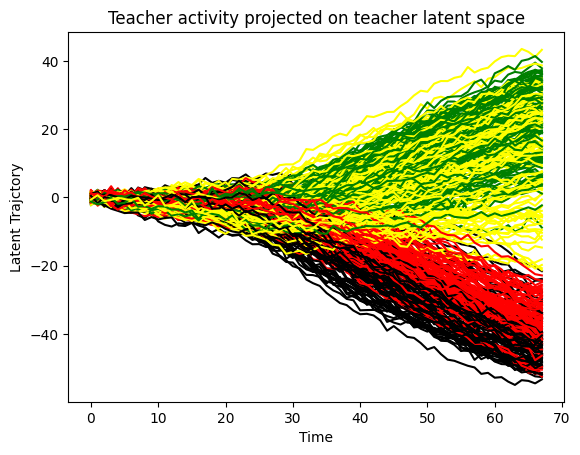

In [50]:
z_teach_teach = task.data @ rnn_reach.rnn.m
for b in range(z_teach_teach.shape[0]):
    trial = z_teach_teach[b].detach().cpu().numpy()
    if task.s[b, :, 0].max() > 0 and task.stim[b, :, 0].mean() > 0:
        plt.plot(np.arange(0, len(trial)), trial, c='r')
    elif task.s[b, :, 0].max() > 0 and task.stim[b, :, 0].mean() < 0:
        plt.plot(np.arange(0, len(trial)), trial, c='g')
    elif task.s[b, :, 1].max() > 0 and task.stim[b, :, 1].mean() > 0:
        plt.plot(np.arange(0, len(trial)), trial, c='black')
    elif task.s[b, :, 1].max() > 0 and task.stim[b, :, 1].mean() < 0:
        plt.plot(np.arange(0, len(trial)), trial, c='yellow')
plt.xlabel('Time')
plt.ylabel('Latent Trajctory')
plt.title('Teacher activity projected on teacher latent space')

Text(0.5, 1.0, 'Recovering neuromodulation weights')

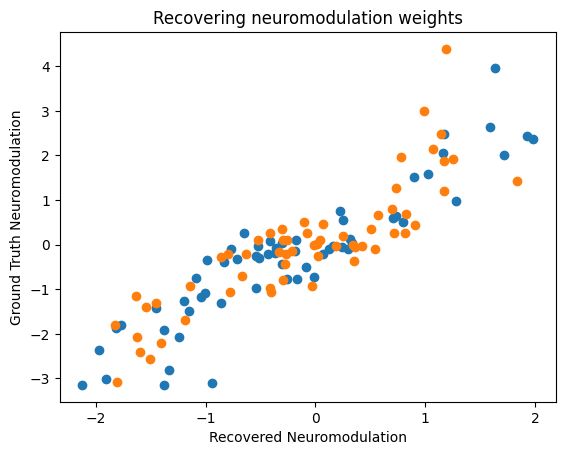

In [51]:
# w_inp = np.load(''.join([data_dir, 'teacher_winp.npy']))
plt.scatter(model.rnn.transition.Wu[:, 0].detach().cpu().numpy(), rnn_reach.rnn.w_inp[0, :].detach().numpy())
plt.scatter(model.rnn.transition.Wu[:, 1].detach().cpu().numpy(), rnn_reach.rnn.w_inp[1, :].detach().numpy())
plt.xlabel('Recovered Neuromodulation')
plt.ylabel('Ground Truth Neuromodulation')
plt.title('Recovering neuromodulation weights')

Text(0.5, 1.0, 'Recovering Input weights')

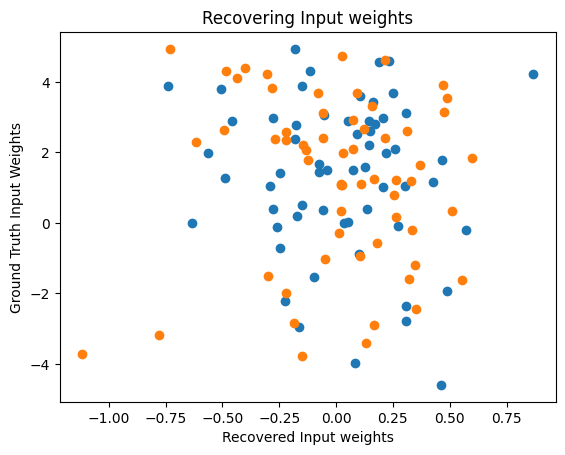

In [53]:
plt.scatter(model.rnn.transition.A[:, 0].detach().numpy(), rnn_reach.rnn.A[:, 0].detach().numpy())
plt.scatter(model.rnn.transition.A[:, 1].detach().numpy(), rnn_reach.rnn.A[:, 1].detach().numpy())
plt.xlabel('Recovered Input weights')
plt.ylabel('Ground Truth Input Weights')
plt.title('Recovering Input weights')

In [28]:
model.rnn.transition.nm_params

Parameter containing:
tensor([[1.3669, 0.7645],
        [1.0523, 0.7738],
        [0.9947, 1.1871],
        [1.2074, 0.9127],
        [0.7645, 0.9318],
        [0.8913, 0.9735],
        [1.1153, 1.1187],
        [1.0076, 1.0045],
        [0.5470, 1.5579],
        [1.4563, 0.7490],
        [0.8754, 1.1476],
        [0.5650, 1.0493],
        [0.9283, 1.2362],
        [1.0701, 0.8850],
        [0.8672, 1.1116],
        [1.1624, 1.0006],
        [0.8644, 0.9260],
        [0.6437, 1.2825],
        [1.3768, 0.1170],
        [0.1534, 1.0669],
        [1.4820, 1.3786],
        [1.1914, 0.7564],
        [1.4459, 0.8432],
        [1.5693, 0.3912],
        [0.5882, 1.4849],
        [1.0106, 0.9952],
        [0.7495, 1.1996],
        [0.5403, 1.3450],
        [1.1987, 0.8939],
        [0.8286, 1.1930],
        [0.9582, 1.0440],
        [1.4256, 0.6103],
        [0.8150, 1.2735],
        [1.0832, 1.2526],
        [1.2569, 0.8213],
        [1.0109, 0.9323],
        [1.1796, 1.0409],
        [0.9206,

In [ ]:
# extract teacher RNN data
batch_size=12
task_params['n_trials']=batch_size
# task = RDM_Teacher(task_params, task_params_teacher, U, V, B, I, decay=0.9)
# data_loader = DataLoader(task, batch_size=batch_size, shuffle=False)

ratesGT = task.data
latent_codeGT = task.latents

# run the student RNN
with torch.no_grad():
    z0 = torch.zeros(batch_size,1,1,1)
    stim = task.stim.permute(0, 2, 1)
    dur=task.dur
    Z, v = vae.rnn.get_latent_time_series(time_steps=dur, z0=z0, u=stim, noise_scale=1,sim_v=True)
    Zn = Z.cpu().detach().numpy()[:, :, :, 0]
    data_gen = (
        vae.rnn.get_observation(Z, v=v,noise_scale=1).cpu().detach().numpy()[:, :, :, 0]
    )

/var/folders/7z/c9g_hq_9025gxx730qgmlh4w0000gn/T/ipykernel_9340/1574588498.py:20: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  fig.legend([idx_i, idx_j], labels=['Neural activity', 'Predicted Neural activity'], loc='upper right')


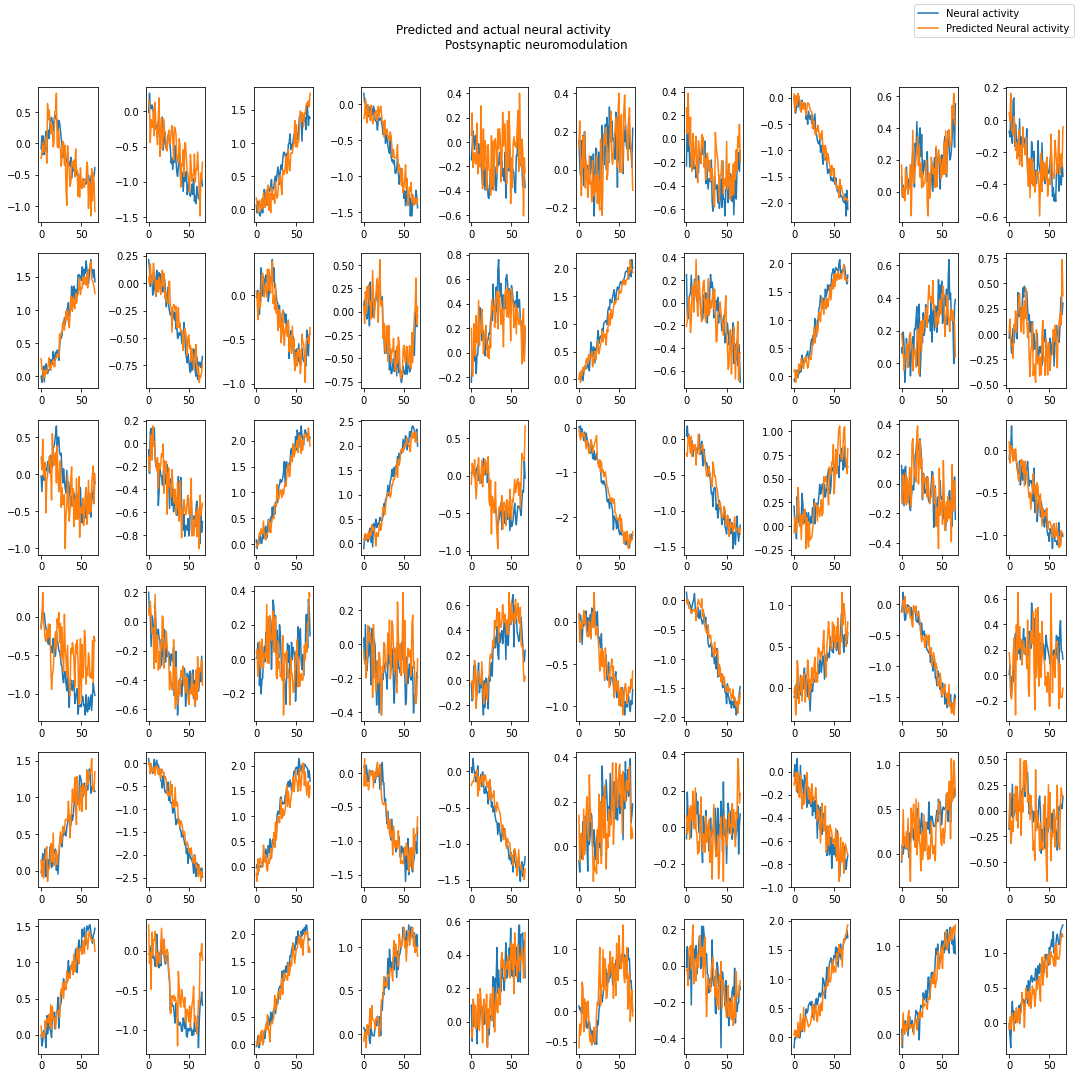

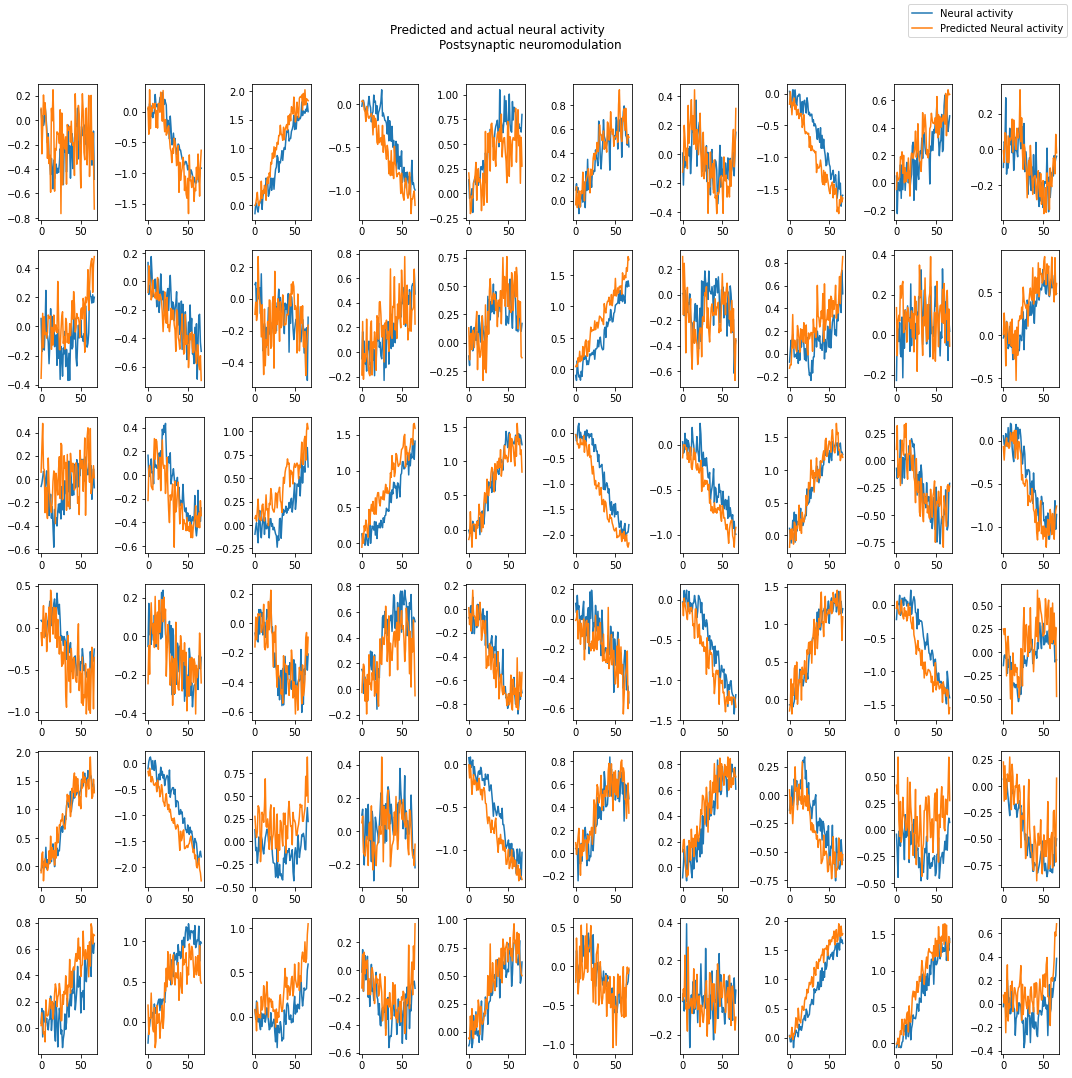

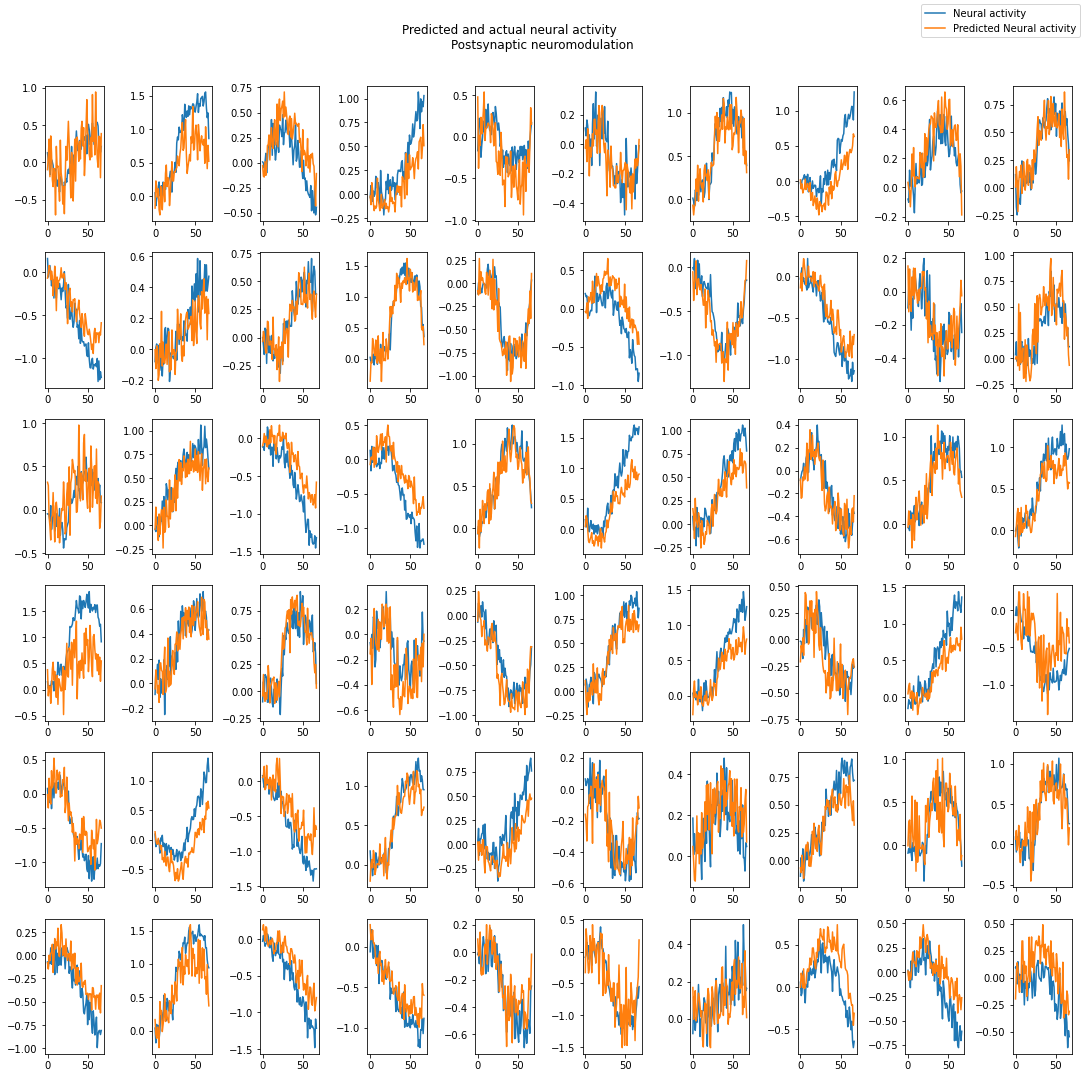

In [18]:
import matplotlib.pyplot as plt 
kl_div = []
for b in range(3):
    # compute the KL-Divergence 
    #kl_div_b = compute_KL_divergence(X_pred[b].unsqueeze(0), x[b])
    #kl_div.append(kl_div_b) 
    # plot population activity 
    fig, ax = plt.subplots(6, 10, figsize=(15, 15))
    idx_i, idx_j = 0, 0
    for i in range(task_params["n_neurons"]):
        ax[idx_i, idx_j].plot(ratesGT[i,b], label=f'Neural activity')
        #ax[idx_i, idx_j].plot(x[b+1, :, i], label=f'Neural activity')
        #ax[idx_i, idx_j].plot(X_pred[b+1, :, i], label=f'Predicted Neural activity')

        ax[idx_i, idx_j].plot(data_gen[b,i], label=f'Predicted Neural activity')
        idx_j += 1
        if idx_j >= 10: 
            idx_i, idx_j = idx_i + 1, 0
        
    fig.legend([idx_i, idx_j], labels=['Neural activity', 'Predicted Neural activity'], loc='upper right')
    fig.suptitle(f"Predicted and actual neural activity\
                 \nPostsynaptic neuromodulation")
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    #fig.savefig(f"{figures_dir}/reaching_unmodulated_{b}.png")
    # plt.show()
    
    

0.6801321547461321


Text(0.5, 1.0, 'Pearson $R$ heatmap')

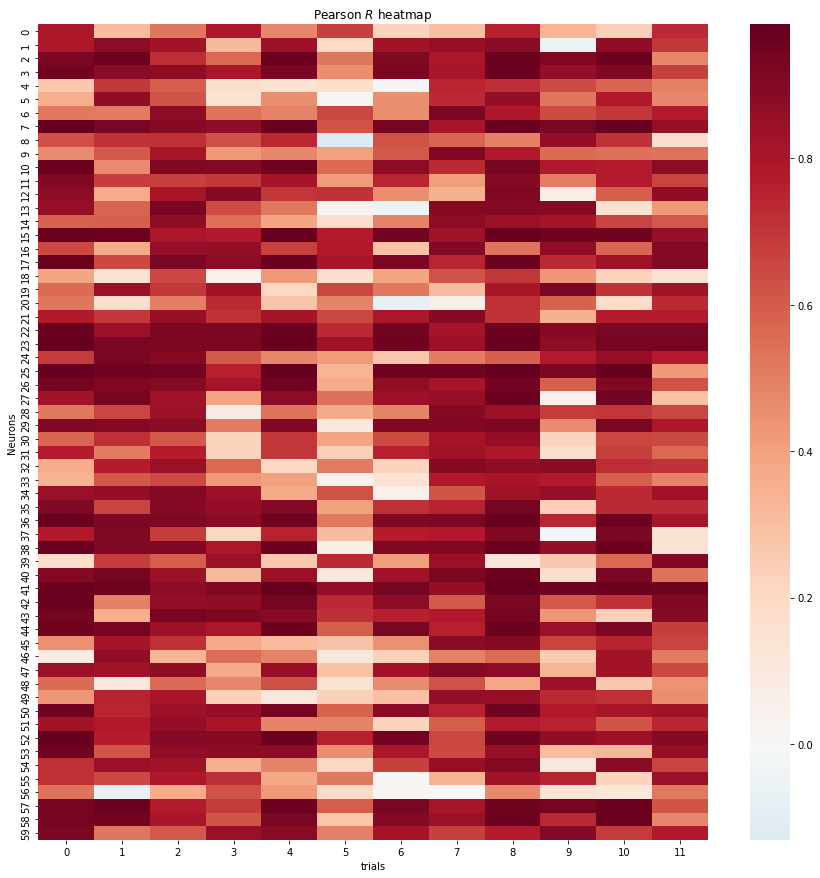

In [23]:
import seaborn as sns
from scipy.stats import pearsonr
# compute pearson's r

pearson_r = np.zeros((task_params["n_neurons"], data_gen.shape[0]))
for i in range(task_params["n_neurons"]):
    for b in range(data_gen.shape[0]):
        pearson_r[i][b] = pearsonr(ratesGT[i,b],data_gen[b,i])[0]
print(pearson_r.mean())
plt.figure(figsize=(15, 15))
# r2_arr[r2_arr < -1] = -1
sns.heatmap(pearson_r[:, :], annot=False, cmap='RdBu_r', center=0, cbar=True)
# x_ticks = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]
# x_labels = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]
# plt.xticks(x_ticks, x_labels)
plt.ylabel('Neurons')
plt.xlabel('trials')
plt.title(f'Pearson $R$ heatmap')
# plt.savefig('rank_scaling_pearson_r.png')